TITANIC DATASET

First Five Rows
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            37

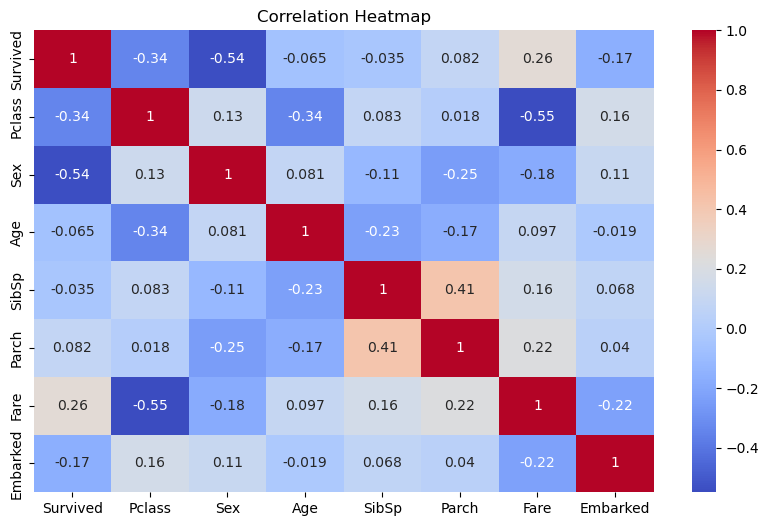


Logistic Regression
Accuracy : 81.01 %

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



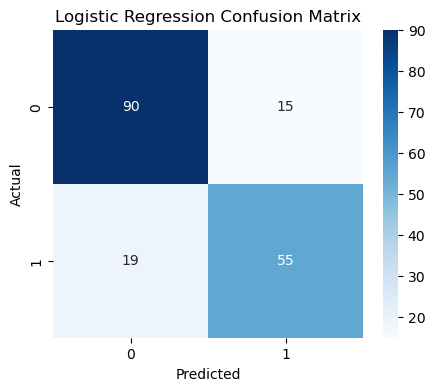


Decision Tree
Accuracy : 78.21 %

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       105
           1       0.72      0.77      0.75        74

    accuracy                           0.78       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.78      0.78       179



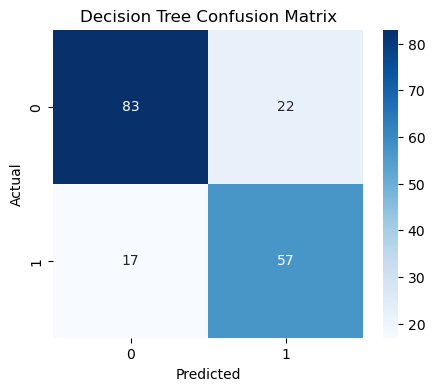


Random Forest
Accuracy : 82.12 %

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



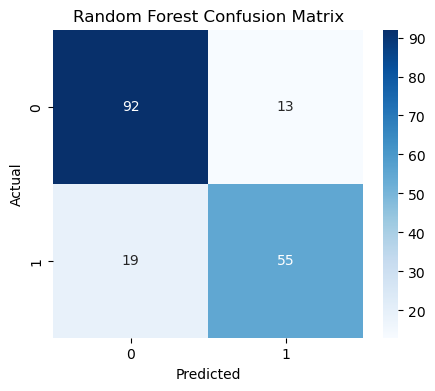


MODEL ACCURACY
                 Model   Accuracy
0  Logistic Regression  81.005587
1        Decision Tree  78.212291
2        Random Forest  82.122905


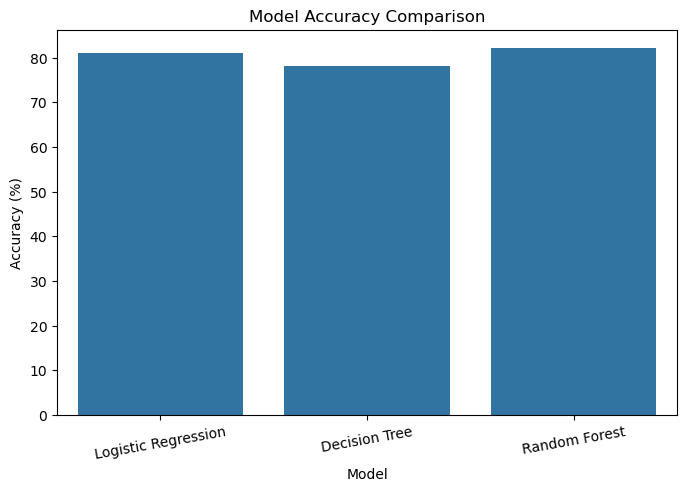


Best Model : Random Forest


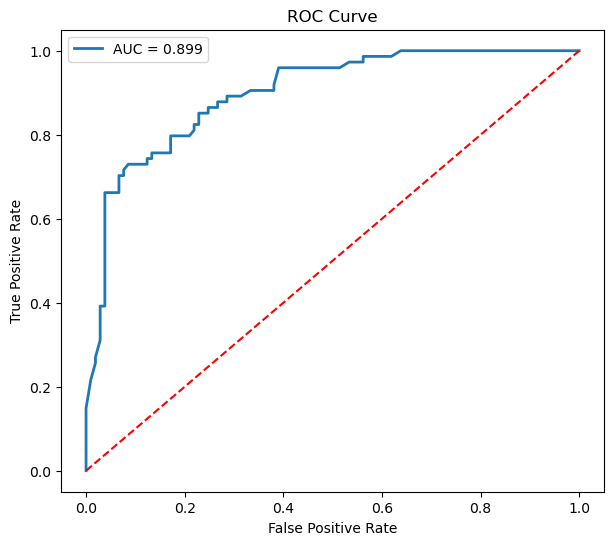

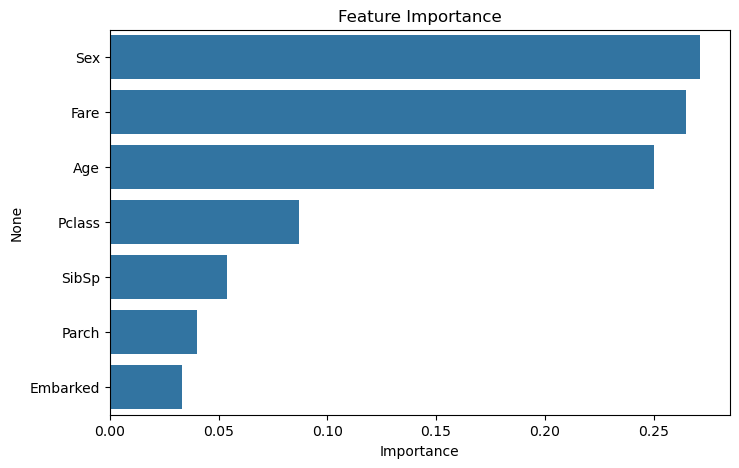


PROJECT INSIGHTS
1. Missing values were handled successfully.
2. Categorical variables were encoded.
3. Three supervised learning models were trained.
4. Model performance was evaluated using accuracy.
5. Confusion matrices were generated.
6. ROC Curve was plotted for the best model.
7. The best-performing model was selected based on accuracy.

CONCLUSION

This project demonstrates predictive modeling using supervised machine
learning. The Titanic dataset was cleaned by handling missing values,
encoding categorical variables, and removing unnecessary columns.
Three machine learning algorithms—Logistic Regression, Decision Tree,
and Random Forest—were trained and evaluated using a train-test split.
Performance was measured using accuracy, confusion matrices,
classification reports, and the ROC curve. The model with the highest
accuracy was identified as the best-performing model for predicting
Titanic passenger survival.



In [3]:
# ==========================================================
# Predictive Modeling Using Machine Learning
# Titanic Survival Prediction
# ==========================================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# ----------------------------------------------------------
# Load Dataset
# ----------------------------------------------------------
df = pd.read_csv("train.csv")

print("="*70)
print("TITANIC DATASET")
print("="*70)

print("\nFirst Five Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns.tolist())

print("\nDataset Information")
print(df.info())

print("\nStatistical Summary")
print(df.describe(include="all"))

print("\nMissing Values Before Cleaning")
print(df.isnull().sum())

# ----------------------------------------------------------
# Remove Duplicates
# ----------------------------------------------------------
duplicates = df.duplicated().sum()
print("\nDuplicate Rows:", duplicates)

df.drop_duplicates(inplace=True)

# ----------------------------------------------------------
# Handle Missing Values
# ----------------------------------------------------------
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["Cabin"] = df["Cabin"].fillna("Unknown")

print("\nMissing Values After Cleaning")
print(df.isnull().sum())

# ----------------------------------------------------------
# Encode Categorical Columns
# ----------------------------------------------------------
encoder = LabelEncoder()

df["Sex"] = encoder.fit_transform(df["Sex"])
df["Embarked"] = encoder.fit_transform(df["Embarked"])

# ----------------------------------------------------------
# Drop Unnecessary Columns
# ----------------------------------------------------------
df.drop(["PassengerId","Name","Ticket","Cabin"],axis=1,inplace=True)

# ----------------------------------------------------------
# Correlation Heatmap
# ----------------------------------------------------------
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# ----------------------------------------------------------
# Features and Target
# ----------------------------------------------------------
X = df.drop("Survived",axis=1)
y = df["Survived"]

# ----------------------------------------------------------
# Train Test Split
# ----------------------------------------------------------
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ----------------------------------------------------------
# Machine Learning Models
# ----------------------------------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

results = {}

# ----------------------------------------------------------
# Train Models
# ----------------------------------------------------------
for name,model in models.items():

    model.fit(X_train,y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test,y_pred)

    results[name] = accuracy

    print("\n"+"="*70)
    print(name)
    print("="*70)

    print("Accuracy :",round(accuracy*100,2),"%")

    print("\nClassification Report")
    print(classification_report(y_test,y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test,y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(name+" Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

# ----------------------------------------------------------
# Accuracy Comparison
# ----------------------------------------------------------
accuracy_df = pd.DataFrame({
    "Model":results.keys(),
    "Accuracy":[score*100 for score in results.values()]
})

print("\n"+"="*70)
print("MODEL ACCURACY")
print("="*70)

print(accuracy_df)

plt.figure(figsize=(8,5))

sns.barplot(
    data=accuracy_df,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=10)

plt.show()

# ----------------------------------------------------------
# Best Model
# ----------------------------------------------------------
best_model_name = max(results,key=results.get)

print("\nBest Model :",best_model_name)

best_model = models[best_model_name]

# ----------------------------------------------------------
# ROC Curve
# ----------------------------------------------------------
if hasattr(best_model,"predict_proba"):

    y_prob = best_model.predict_proba(X_test)[:,1]

    fpr,tpr,threshold = roc_curve(y_test,y_prob)

    roc_auc = auc(fpr,tpr)

    plt.figure(figsize=(7,6))

    plt.plot(
        fpr,
        tpr,
        label="AUC = %.3f"%roc_auc,
        linewidth=2
    )

    plt.plot([0,1],[0,1],"r--")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()

    plt.show()

# ----------------------------------------------------------
# Feature Importance
# ----------------------------------------------------------
if best_model_name=="Random Forest":

    importance = pd.Series(
        best_model.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)

    plt.figure(figsize=(8,5))

    sns.barplot(
        x=importance.values,
        y=importance.index
    )

    plt.title("Feature Importance")
    plt.xlabel("Importance")

    plt.show()

# ----------------------------------------------------------
# Final Insights
# ----------------------------------------------------------
print("\n"+"="*70)
print("PROJECT INSIGHTS")
print("="*70)

print("1. Missing values were handled successfully.")
print("2. Categorical variables were encoded.")
print("3. Three supervised learning models were trained.")
print("4. Model performance was evaluated using accuracy.")
print("5. Confusion matrices were generated.")
print("6. ROC Curve was plotted for the best model.")
print("7. The best-performing model was selected based on accuracy.")

# ----------------------------------------------------------
# Conclusion
# ----------------------------------------------------------
print("\n"+"="*70)
print("CONCLUSION")
print("="*70)

print("""
This project demonstrates predictive modeling using supervised machine
learning. The Titanic dataset was cleaned by handling missing values,
encoding categorical variables, and removing unnecessary columns.
Three machine learning algorithms—Logistic Regression, Decision Tree,
and Random Forest—were trained and evaluated using a train-test split.
Performance was measured using accuracy, confusion matrices,
classification reports, and the ROC curve. The model with the highest
accuracy was identified as the best-performing model for predicting
Titanic passenger survival.
""")